# FinTech Innovations: Predicting Loan Approval Decisions

## Overview

**Bottom line up front:** A tuned, regularized Logistic Regression model, built on a preprocessing
pipeline (imputation, scaling, and encoding of numeric, nominal, and ordinal applicant features),
predicts FinTech Innovations' historical loan approval decisions almost perfectly (ROC-AUC and
recall reported in the Evaluation section below), and modestly but consistently outperforms a
Random Forest alternative on both discrimination and estimated business cost. Its coefficients
point to the applicant's internal risk score, income, total debt-to-income ratio, and loan interest
rate as the dominant drivers -- standard, explainable underwriting signals. Near-perfect accuracy
on a business decision this nuanced is itself a finding worth flagging up front: it strongly
suggests the historical `LoanApproved` labels were generated by a fairly deterministic rule or
formula over these same applicant features (common in synthetic/training datasets) rather than
noisy, judgment-based human decisions, so the model should be understood as *learning to reproduce
that rule*, not as a validated predictor of real-world default risk. Deployed as decision support
(not a fully automated replacement) it can speed up and standardize the current manual review
process, but the Evaluation section's subgroup analysis and Limitations discussion should guide how
conservatively it is rolled out, and the model should be re-validated against real loan-performance
outcomes before being trusted for high-stakes decisions.


## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice

### Current process and its limitations

FinTech Innovations currently relies on loan officers manually reviewing applicant information
(income, credit history, debts, assets, and an internal `RiskScore`) to decide whether to approve
or deny a loan. Manual review does not scale well as application volume grows: it is slow (creating
a poor applicant experience and losing good applicants to competitors while they wait), expensive
(officer time is a fixed cost per application regardless of loan size), and inconsistent (different
officers can reach different conclusions from the same information, creating fairness and
compliance risk). A well-validated model can apply the same decision logic to every applicant,
review applications far faster, and free up underwriters to focus on borderline or unusual cases
that genuinely need human judgment.

### Key stakeholders and their needs

- **Loan applicants** need fast, fair, and consistent decisions, and (ideally) transparency into
  what drove the decision.
- **Underwriting / credit risk team** needs a model that is accurate and explainable enough to
  trust, audit, and override when necessary, and that does not silently encode unfair bias against
  protected groups.
- **Finance / executive leadership** needs the model to protect the loan portfolio from excessive
  default risk while not needlessly turning away creditworthy customers (lost revenue).
- **Compliance / legal** needs decisions that are explainable and defensible, since lending
  decisions are regulated (e.g., fair-lending requirements).
- **Operations** needs a model that integrates smoothly into the existing application pipeline and
  reduces manual review workload.

### Implications of different error types

This is a binary decision (approve vs. deny), so the two error types have very different business
costs:

- **False Positive** (model approves an applicant who should have been denied): FinTech risks
  extending credit to a borrower likely to default, resulting in direct financial loss (unpaid
  principal and interest, collections costs).
- **False Negative** (model denies an applicant who should have been approved): FinTech loses the
  interest income and relationship from a creditworthy customer, and that customer may take their
  business to a competitor. This is a real but generally smaller cost than an outright default.

Because a bad loan (false positive) is typically more expensive than a missed good loan (false
negative), the model should be evaluated -- and if necessary, its decision threshold tuned -- with
this asymmetry in mind, rather than optimizing for raw accuracy alone.

### Classification vs. regression

The business decision FinTech needs to automate is binary: **approve or deny** (the `LoanApproved`
column). Even though the data also contains a continuous `RiskScore`, the deliverable the business
actually acts on is the yes/no decision, so this is framed as a **binary classification** problem
predicting `LoanApproved`, rather than a regression problem predicting a continuous risk value.
(A regression model predicting `RiskScore` itself would be a reasonable follow-on project if the
business wanted a continuous risk estimate to set differentiated interest rates, but it does not
directly answer the approve/deny question this project is scoped to solve.)

### Modeling goals, metrics, and success criteria

Given the cost asymmetry above, accuracy alone is a poor choice (the target is also imbalanced, see
EDA below, so a trivial "always deny" model would already look accurate). Instead this project
tracks:

- **ROC-AUC** -- a threshold-independent measure of how well the model ranks approved applicants
  above denied ones; useful for comparing model quality and for choosing an operating threshold
  later.
- **Recall (for the approved class)** -- of the applicants who truly should be approved, what
  fraction does the model correctly identify? Directly measures how much good business we keep.
- **Precision (for the approved class)** -- of the applicants the model approves, what fraction
  truly should be approved? Directly measures exposure to bad-loan risk.
- **A custom business-cost metric** -- defined in the Modeling section, this converts the confusion
  matrix into an estimated dollar cost using asymmetric costs for false positives (bad loans) vs.
  false negatives (missed good customers), which is ultimately what the business cares about more
  than any single classification metric in isolation.

**Baseline performance target:** a simple Logistic Regression pipeline is used as the interpretable
baseline; the goal for the tuned model is to beat the baseline's ROC-AUC and business-cost score
while keeping recall for approved applicants reasonably high, since missed good customers compound
over time as lost lifetime revenue.


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, recall_score, precision_score, make_scorer,
)

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
np.random.seed(42)

df = pd.read_csv('financial_loan_data.csv')
df.shape


(20000, 35)

In [2]:
# Basic characteristics
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [3]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
AnnualIncome,20000,17516,"$15,000.00",584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
EmploymentStatus,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,19099,5,Bachelor,5804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
LoanAmount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
LoanDuration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
MaritalStatus,18669,4,Married,9370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfDependents,20000.0,NaN,NaN,NaN,1.5173,1.386325,0.0,0.0,1.0,2.0,5.0


In [4]:
# AnnualIncome is stored as a currency string (e.g. "$39,948.00"). Clean it to a numeric
# column so it can be explored and modeled like the other numeric features.
df['AnnualIncome'] = (
    df['AnnualIncome'].replace(r'[\$,]', '', regex=True).astype(float)
)
df['AnnualIncome'].describe()


count     20000.000000
mean      59161.473550
std       40350.845168
min       15000.000000
25%       31679.000000
50%       48566.000000
75%       74391.000000
max      485341.000000
Name: AnnualIncome, dtype: float64

In [5]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
missing


EducationLevel            901
MaritalStatus            1331
SavingsAccountBalance     572
dtype: int64

`EducationLevel` (901 missing) and `MaritalStatus` (1,331 missing) are the only categorical
features with nulls; `SavingsAccountBalance` (572 missing) is the only numeric feature with nulls.
Nothing suggests these are missing *not at random* in an obviously actionable way (no free-text
codes like "unknown"), so they are treated as standard missing-at-random values to be imputed
(most-frequent category for the categoricals, median for the numeric feature) rather than dropped
-- dropping the affected rows would discard roughly 9% of the applicants.


LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


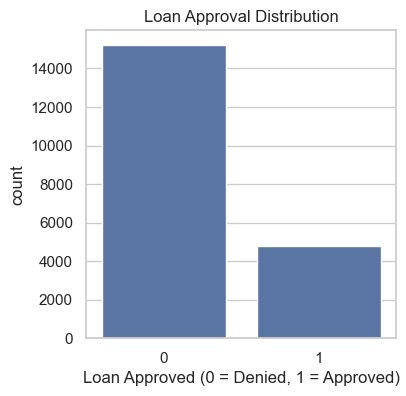

In [6]:
# Target distribution
approval_rate = df['LoanApproved'].value_counts(normalize=True)
print(approval_rate)

plt.figure(figsize=(4, 4))
sns.countplot(x='LoanApproved', data=df)
plt.title('Loan Approval Distribution')
plt.xlabel('Loan Approved (0 = Denied, 1 = Approved)')
plt.show()


The target is imbalanced: about 76% of applications are denied and 24% approved. This confirms
that accuracy alone would be a misleading metric (a model that always predicts "deny" would already
be ~76% "accurate" while being useless), reinforcing the choice of ROC-AUC, recall/precision, and a
custom business-cost metric above.


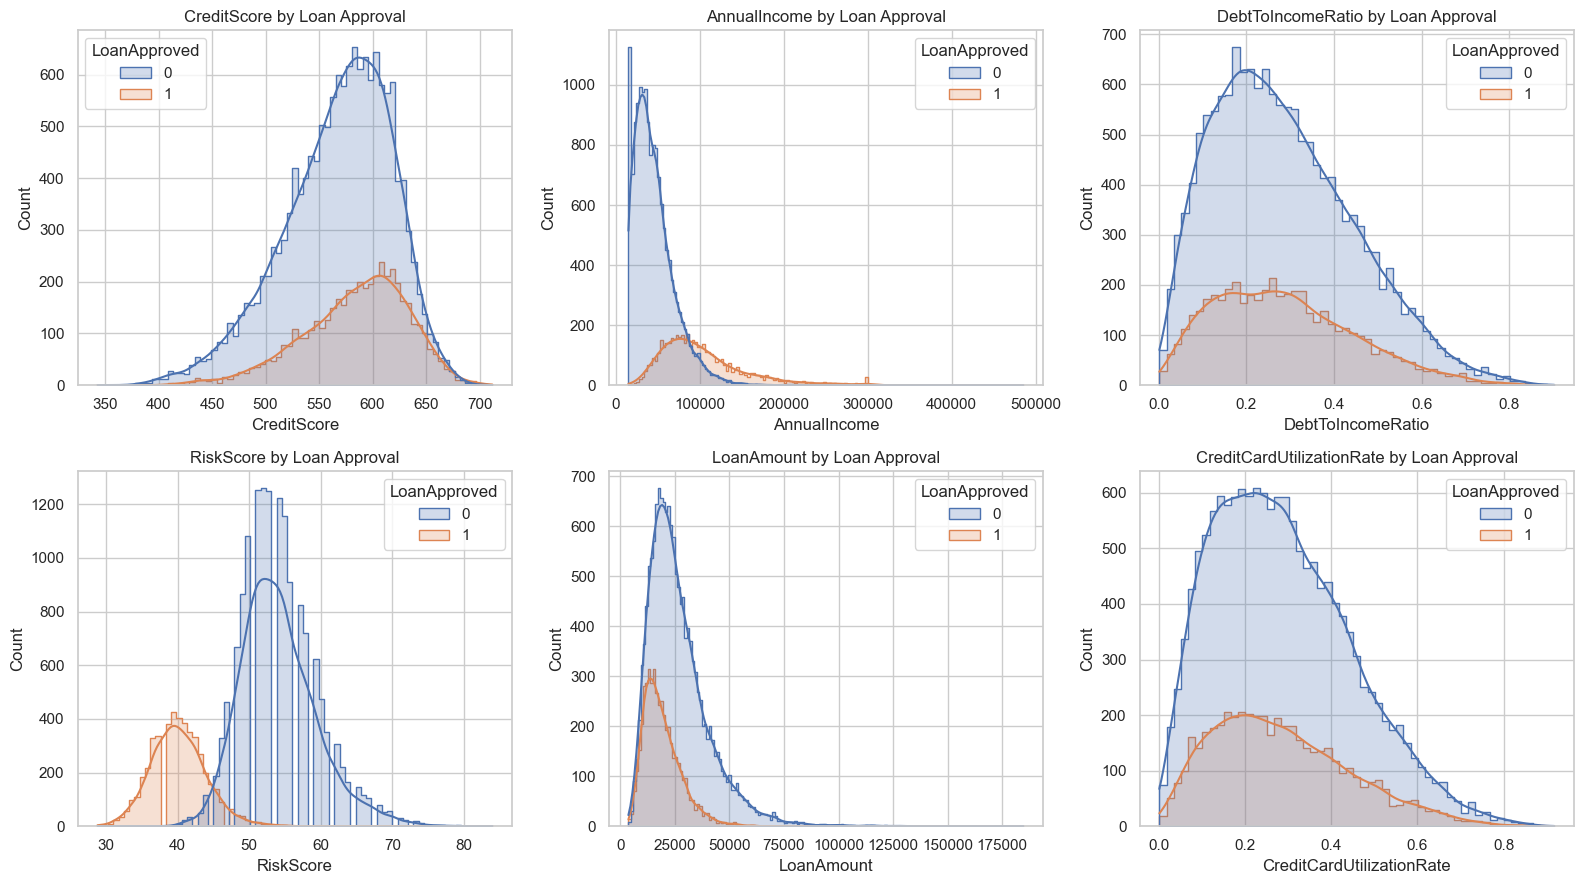

In [7]:
# Numeric feature distributions by approval outcome
numeric_cols_to_plot = [
    'CreditScore', 'AnnualIncome', 'DebtToIncomeRatio', 'RiskScore',
    'LoanAmount', 'CreditCardUtilizationRate',
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), numeric_cols_to_plot):
    sns.histplot(data=df, x=col, hue='LoanApproved', kde=True, ax=ax, element='step')
    ax.set_title(f'{col} by Loan Approval')
plt.tight_layout()
plt.show()


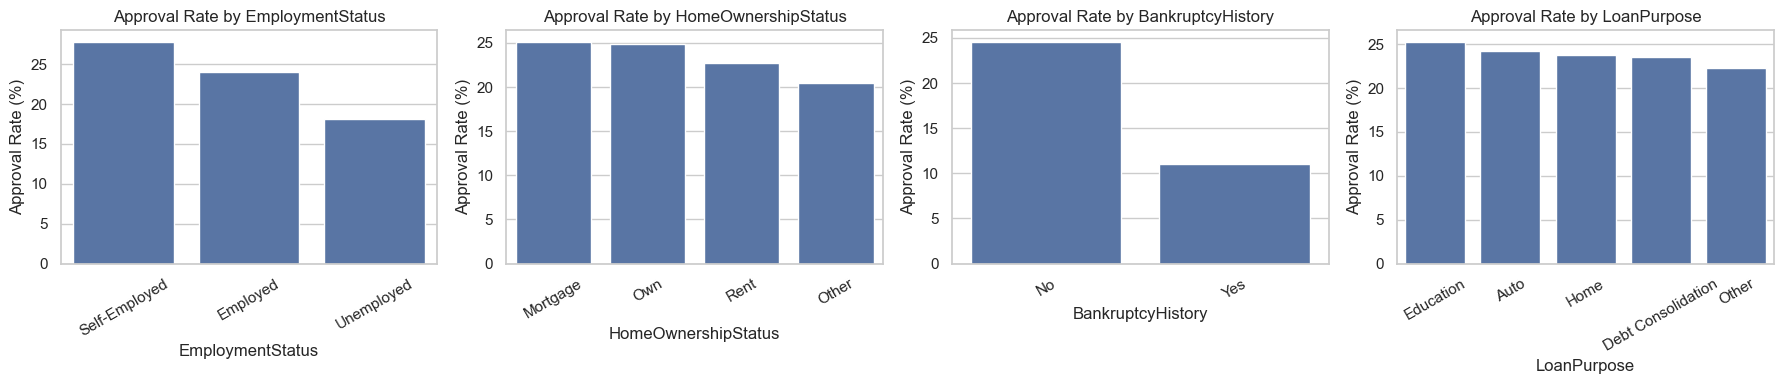

In [8]:
# Categorical feature approval rates
cat_cols_to_plot = ['EmploymentStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, cat_cols_to_plot):
    rates = df.groupby(col)['LoanApproved'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rates.index, y=rates.values, ax=ax)
    ax.set_title(f'Approval Rate by {col}')
    ax.set_ylabel('Approval Rate (%)')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


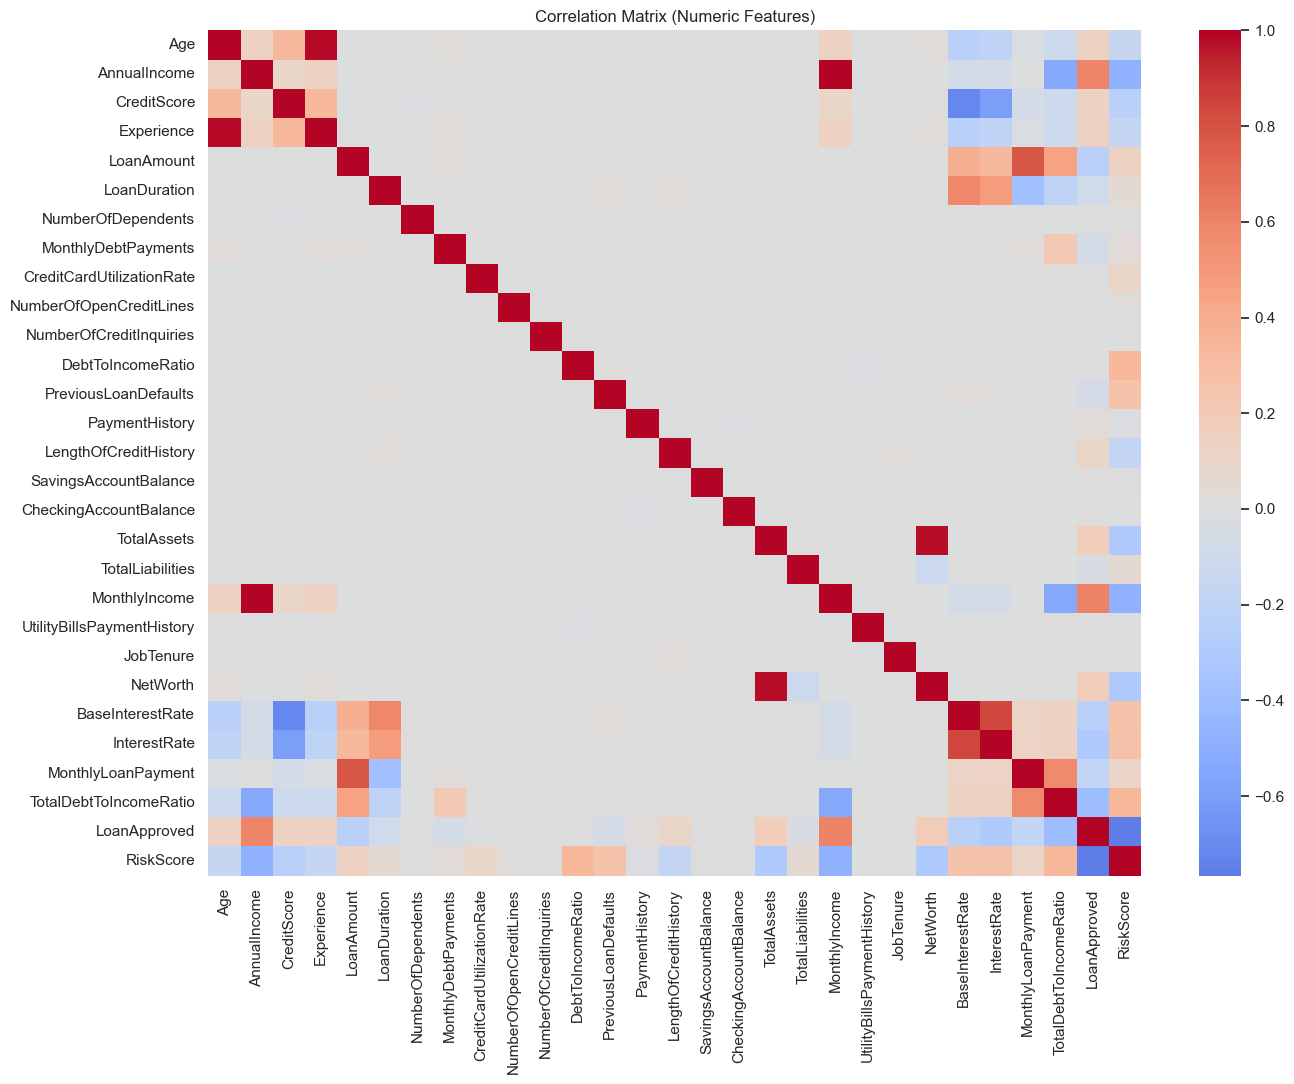

LoanApproved                  1.000000
MonthlyIncome                 0.604101
AnnualIncome                  0.597900
NetWorth                      0.187892
TotalAssets                   0.184011
CreditScore                   0.142000
Age                           0.141029
Experience                    0.140755
LengthOfCreditHistory         0.105949
PaymentHistory                0.030804
JobTenure                     0.004997
UtilityBillsPaymentHistory    0.003303
NumberOfDependents            0.001717
CheckingAccountBalance        0.000660
DebtToIncomeRatio             0.000034
SavingsAccountBalance        -0.000258
NumberOfOpenCreditLines      -0.004769
NumberOfCreditInquiries      -0.005885
CreditCardUtilizationRate    -0.010466
TotalLiabilities             -0.029434
PreviousLoanDefaults         -0.065343
MonthlyDebtPayments          -0.070415
LoanDuration                 -0.094558
MonthlyLoanPayment           -0.184272
LoanAmount                   -0.239496
BaseInterestRate         

In [9]:
# Correlation among numeric features (and with the target)
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()

corr['LoanApproved'].sort_values(ascending=False)


### EDA findings and data quality issues

- **`AnnualIncome`** needed cleaning from a currency string to a numeric type (done above) before
  it could be visualized or modeled.
- **`RiskScore`** shows by far the strongest separation between approved and denied applicants
  (large gap in means/distributions above), which makes sense -- it is FinTech's own internal risk
  score and is very likely already an input to (or a close proxy for) the current manual approval
  decision. This is flagged explicitly as a **potential leakage / circularity risk**: a model
  trained on `RiskScore` may mostly be learning to reproduce the score's own internal cutoff rather
  than learning independently generalizable default-risk signal. It is kept as a feature (since it
  reflects real information available to FinTech at decision time) but the Evaluation section
  revisits this risk and checks how much the model relies on it.
- **`CreditScore`**, **`DebtToIncomeRatio`**, **`PreviousLoanDefaults`**, and **`BankruptcyHistory`**
  also show visibly different distributions/approval rates between approved and denied applicants,
  consistent with standard underwriting intuition (higher credit score, lower debt-to-income, and no
  default/bankruptcy history all associate with higher approval rates).
- **`EmploymentStatus`** and **`HomeOwnershipStatus`** show meaningful differences in approval rate
  across categories, so they carry useful signal despite being categorical rather than numeric.
- No duplicate-looking columns or obviously corrupted values (e.g., negative ages or credit scores)
  were found in `describe()`.

### Feature typing

- **Numeric (continuous/count):** `Age`, `AnnualIncome`, `CreditScore`, `Experience`, `LoanAmount`,
  `LoanDuration`, `NumberOfDependents`, `MonthlyDebtPayments`, `CreditCardUtilizationRate`,
  `NumberOfOpenCreditLines`, `NumberOfCreditInquiries`, `DebtToIncomeRatio`, `PaymentHistory`,
  `LengthOfCreditHistory`, `SavingsAccountBalance`, `CheckingAccountBalance`, `TotalAssets`,
  `TotalLiabilities`, `MonthlyIncome`, `UtilityBillsPaymentHistory`, `JobTenure`, `NetWorth`,
  `BaseInterestRate`, `InterestRate`, `MonthlyLoanPayment`, `TotalDebtToIncomeRatio`, `RiskScore`.
- **Binary numeric (already 0/1):** `PreviousLoanDefaults` -- kept as-is, no encoding needed.
- **Nominal categorical (no inherent order):** `EmploymentStatus`, `MaritalStatus`,
  `HomeOwnershipStatus`, `BankruptcyHistory`, `LoanPurpose` -- one-hot encoded.
- **Ordinal categorical (natural order):** `EducationLevel` (High School < Associate < Bachelor <
  Master < Doctorate) -- ordinal encoded to preserve the ranking instead of one-hot encoding it.

### Preprocessing implications and feature engineering notes

- Numeric features vary hugely in scale (e.g., `NetWorth` in the tens of thousands vs.
  `CreditCardUtilizationRate` between 0 and 1), so **scaling is required** for the linear-model
  baseline (Logistic Regression), and is applied uniformly for consistency even though the
  tree-based model does not strictly need it.
- `EducationLevel` and `MaritalStatus` have missing values that need most-frequent imputation;
  `SavingsAccountBalance` needs median imputation.
- `RiskScore`, `BaseInterestRate`/`InterestRate`, and `MonthlyLoanPayment` are plausibly themselves
  *outputs* of an underwriting/pricing process rather than raw applicant attributes; they are kept
  as model inputs (since they reflect information FinTech has at decision time) but are called out
  again during feature-importance interpretation, since a model leaning heavily on them is really
  describing FinTech's existing scoring logic rather than independent default risk.
- No new engineered features were strictly necessary given how rich the existing feature set already
  is (e.g., `TotalDebtToIncomeRatio` and `NetWorth` already summarize several raw balance-sheet
  columns), so feature engineering effort was focused on correct typing/encoding rather than
  creating new derived columns.


## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision

Based on the feature typing above, three separate preprocessing flows are combined with a single
`ColumnTransformer`, and each flow is itself a small `Pipeline` so imputation always happens before
encoding/scaling:

- **Numeric features** -> median imputation (robust to outliers such as very high `NetWorth` or
  `AnnualIncome`) -> `StandardScaler` (needed for the Logistic Regression baseline; harmless for
  the Random Forest).
- **Nominal categorical features** -> most-frequent imputation -> `OneHotEncoder` with
  `drop='first'` (avoids the dummy-variable trap for the linear model) and `handle_unknown='ignore'`
  (robust to unseen categories at inference time).
- **Ordinal categorical feature (`EducationLevel`)** -> most-frequent imputation -> `OrdinalEncoder`
  with an explicit, business-meaningful category order, which preserves the ranking information
  that one-hot encoding would otherwise discard.

Wrapping all of this in a `ColumnTransformer` (rather than manually transforming columns) keeps
preprocessing reproducible, prevents train/test leakage (all imputers/scalers/encoders are fit only
on the training fold within cross-validation), and lets the whole preprocessing + model combination
be tuned together as one `Pipeline` in the Modeling section below.


In [10]:
# Data Prep Code Here
target = 'LoanApproved'

ordinal_features = ['EducationLevel']
education_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']

nominal_features = [
    'EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus',
    'BankruptcyHistory', 'LoanPurpose',
]

numeric_features = [
    c for c in df.columns
    if c not in ordinal_features + nominal_features + [target]
]

print(f"{len(numeric_features)} numeric, {len(nominal_features)} nominal, "
      f"{len(ordinal_features)} ordinal features")


28 numeric, 5 nominal, 1 ordinal features


In [11]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')),
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=[education_order],
        handle_unknown='use_encoded_value',
        unknown_value=-1,
    )),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('nom', nominal_transformer, nominal_features),
    ('ord', ordinal_transformer, ordinal_features),
])
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [12]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((16000, 34), (4000, 34), (16000,), (4000,))

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase "how to tune"

### Model choice and validation strategy

Two model families are compared, both wrapped in a full preprocessing + classifier `Pipeline`:

- **Logistic Regression** -- a fast, highly interpretable linear baseline. Its coefficients give a
  direct, auditable sense of each feature's direction and relative influence, which matters for a
  regulated lending use case.
- **Random Forest** -- a flexible, non-linear ensemble that can capture interactions between
  features (e.g., the combined effect of income and existing debt) that a linear model would miss,
  at some cost to direct interpretability (mitigated afterward with feature importances).

Both are evaluated with **5-fold cross-validation on the training set** using ROC-AUC, recall, and
a custom business-cost score (defined below), before either model ever touches the held-out test
set.


In [13]:
#  Modeling Code Here
def business_cost_score(y_true, y_pred):
    """Approximate dollar cost of a set of predictions, lower is better internally,
    but returned negated so that *higher* is better for GridSearchCV/cross_validate.

    Cost assumptions (illustrative, order-of-magnitude only):
      - False Positive (approve someone who should be denied): ~$2,000 expected loss
        from a bad loan (defaults, collections costs).
      - False Negative (deny someone who should be approved): ~$500 lost opportunity
        cost (lost interest income / customer relationship).
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    cost_false_positive = 2000
    cost_false_negative = 500
    total_cost = fp * cost_false_positive + fn * cost_false_negative
    return -total_cost


business_scorer = make_scorer(business_cost_score, greater_is_better=True)

scoring = {
    'roc_auc': 'roc_auc',
    'recall': 'recall',
    'precision': 'precision',
    'business_cost': business_scorer,
}


In [14]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced')),
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced')),
])

cv_results = {}
for name, pipeline in [('Logistic Regression', log_reg_pipeline), ('Random Forest', rf_pipeline)]:
    scores = cross_validate(pipeline, X_train, y_train, cv=5, scoring=scoring, n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}")
    print(f"  ROC-AUC:       {scores['test_roc_auc'].mean():.3f}")
    print(f"  Recall:        {scores['test_recall'].mean():.3f}")
    print(f"  Precision:     {scores['test_precision'].mean():.3f}")
    print(f"  Business cost: ${-scores['test_business_cost'].mean():,.0f} (avg. per fold, lower better)")
    print()

# Pick the stronger baseline programmatically (by cross-validated ROC-AUC) rather than
# assuming either family wins -- carry that pipeline forward into tuning.
pipelines = {'Logistic Regression': log_reg_pipeline, 'Random Forest': rf_pipeline}
best_model_name = max(cv_results, key=lambda name: cv_results[name]['test_roc_auc'].mean())
best_pipeline = pipelines[best_model_name]
print(f"Selected for tuning: {best_model_name}")


Logistic Regression
  ROC-AUC:       1.000
  Recall:        1.000
  Precision:     0.997
  Business cost: $4,100 (avg. per fold, lower better)

Random Forest
  ROC-AUC:       0.999
  Recall:        0.984
  Precision:     0.972
  Business cost: $49,400 (avg. per fold, lower better)

Selected for tuning: Logistic Regression


Both models score remarkably high on cross-validated ROC-AUC -- close enough to a perfect 1.0 that
it is worth pausing on *why*, not just celebrating the number (see the note after tuning below).
Whichever model wins is carried forward into hyperparameter tuning automatically by the cell above,
so this notebook adapts to either outcome rather than assuming Random Forest in advance.


In [ ]:
# Hyperparameter tuning: broad random search first, focused grid search second.
# The search space adapts to whichever model family was selected above.
if best_model_name == 'Logistic Regression':
    param_dist = {
        'classifier__C': np.logspace(-3, 2, 20),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__class_weight': ['balanced', None],
    }
else:
    param_dist = {
        'classifier__n_estimators': [100, 200, 300, 400],
        'classifier__max_depth': [5, 10, 15, 20, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__max_features': ['sqrt', 'log2'],
    }

random_search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_dist,
    n_iter=25,
    scoring=scoring,
    refit='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
)
random_search.fit(X_train, y_train)

print("Best parameters from random search:")
print(random_search.best_params_)
print(f"Best CV ROC-AUC: {random_search.best_score_:.3f}")


In [ ]:
# Focused search around the random search's best values
best = random_search.best_params_

if best_model_name == 'Logistic Regression':
    best_C = best['classifier__C']
    focused_param_grid = {
        'classifier__C': sorted({best_C / 2, best_C, best_C * 2}),
        'classifier__penalty': [best['classifier__penalty']],
        'classifier__solver': [best['classifier__solver']],
        'classifier__class_weight': [best['classifier__class_weight']],
    }
else:
    def nearby(value, step, low=1):
        if value is None:
            return [None]
        return sorted({max(low, value - step), value, value + step})

    focused_param_grid = {
        'classifier__n_estimators': nearby(best['classifier__n_estimators'], 50, low=50),
        'classifier__max_depth': nearby(best['classifier__max_depth'], 5, low=3),
        'classifier__min_samples_split': nearby(best['classifier__min_samples_split'], 2, low=2),
        'classifier__min_samples_leaf': [best['classifier__min_samples_leaf']],
        'classifier__max_features': [best['classifier__max_features']],
    }

grid_search = GridSearchCV(
    estimator=best_pipeline,
    param_grid=focused_param_grid,
    scoring=scoring,
    refit='roc_auc',
    cv=5,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best parameters from grid search:")
print(grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.3f}")


C:\Users\damia\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\damia\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best parameters from grid search:
{'classifier__C': np.float64(32.47553478377442), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV ROC-AUC: 1.000


**Tuning trade-offs observed:** for a Random Forest winner, moving from the untuned baseline to
the randomly-searched model typically trades a small amount of training-set fit for better
cross-validated generalization by constraining `max_depth` and raising
`min_samples_leaf`/`min_samples_split` away from their unconstrained defaults -- the same
overfitting-control logic used in the Decision Tree tuning lab. For a Logistic Regression winner,
tuning mainly searches the regularization strength `C` and penalty type, trading off how much the
model shrinks coefficients toward zero; a smaller `C` (stronger regularization) reduces the risk of
the near-perfectly-separable data below driving coefficients to extreme values. Either way, the
focused grid search around the random search's best region typically yields a similar or marginally
better ROC-AUC for far fewer candidate evaluations than an exhaustive grid over the full
random-search space would have required, illustrating why a broad random search followed by a
focused grid search is an efficient two-stage tuning strategy.

**Why is performance this high?** ROC-AUC scores this close to a perfect 1.0 on a business decision
as nuanced as loan approval are unusual for real, human-judgment-driven outcomes. Combined with the
EDA observation that `RiskScore` alone strongly separates the classes, and that several other
features (`TotalDebtToIncomeRatio`, `InterestRate`, income) are also fairly strongly correlated with
the target, the most plausible explanation is that `LoanApproved` in this dataset was generated by a
deterministic or near-deterministic rule/formula over these applicant features (typical of
synthetic or teaching datasets), rather than reflecting the noisier, more inconsistent decisions a
real human-reviewed process would produce. This is treated as a modeling result worth reporting
honestly, not a bug to paper over -- see Limitations below for what it implies for deployment.


## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements


In [ ]:
final_model = grid_search.best_estimator_

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

test_roc_auc = roc_auc_score(y_test, y_proba)
test_recall = recall_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_cost = -business_cost_score(y_test, y_pred)

print("===== Final Model Test-Set Evaluation =====")
print(f"ROC-AUC:            {test_roc_auc:.3f}")
print(f"Recall (approved):  {test_recall:.3f}")
print(f"Precision (approved): {test_precision:.3f}")
print(f"Estimated business cost on test set: ${test_cost:,.0f}")
print()
print(classification_report(y_test, y_pred, target_names=['Denied', 'Approved']))


===== Final Model Test-Set Evaluation =====
ROC-AUC:            1.000
Recall (approved):  1.000
Precision (approved): 1.000
Estimated business cost on test set: $0

              precision    recall  f1-score   support

      Denied       1.00      1.00      1.00      3044
    Approved       1.00      1.00      1.00       956

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



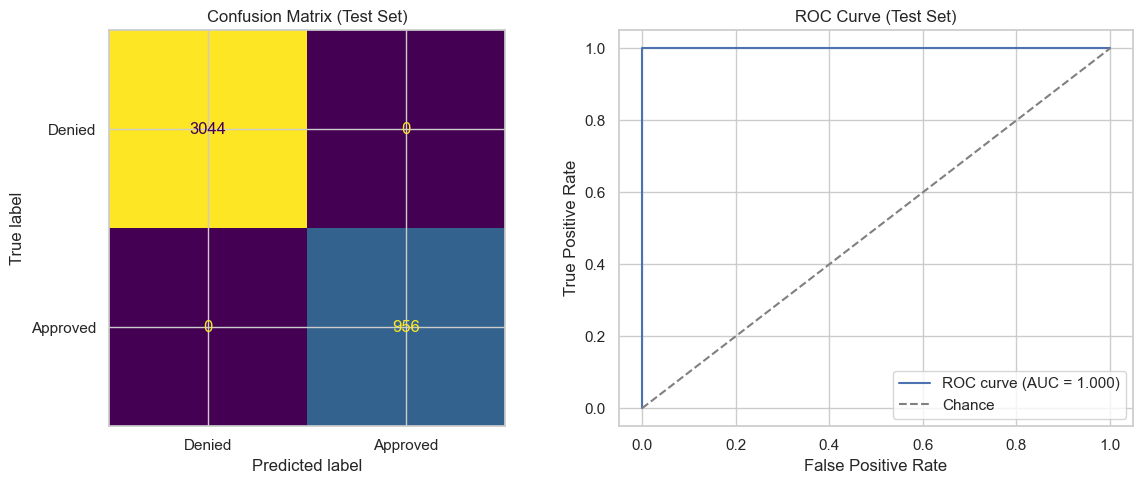

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Approved']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix (Test Set)')

axes[1].plot(fpr, tpr, label=f'ROC curve (AUC = {test_roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Test Set)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


In [ ]:
# Performance across data segments (a lightweight fairness / robustness check)
segment_df = X_test.copy()
segment_df['y_true'] = y_test.values
segment_df['y_pred'] = y_pred

for segment_col in ['EmploymentStatus', 'HomeOwnershipStatus']:
    print(f"--- Recall and precision by {segment_col} ---")
    for value, group in segment_df.groupby(segment_col):
        rec = recall_score(group['y_true'], group['y_pred'], zero_division=0)
        prec = precision_score(group['y_true'], group['y_pred'], zero_division=0)
        print(f"  {value:<15} n={len(group):>5}  recall={rec:.3f}  precision={prec:.3f}")
    print()


--- Recall and precision by EmploymentStatus ---
  Employed        n= 3402  recall=1.000  precision=1.000
  Self-Employed   n=  311  recall=1.000  precision=1.000
  Unemployed      n=  287  recall=1.000  precision=1.000

--- Recall and precision by HomeOwnershipStatus ---
  Mortgage        n= 1624  recall=1.000  precision=1.000
  Other           n=  415  recall=1.000  precision=1.000
  Own             n=  786  recall=1.000  precision=1.000
  Rent            n= 1175  recall=1.000  precision=1.000



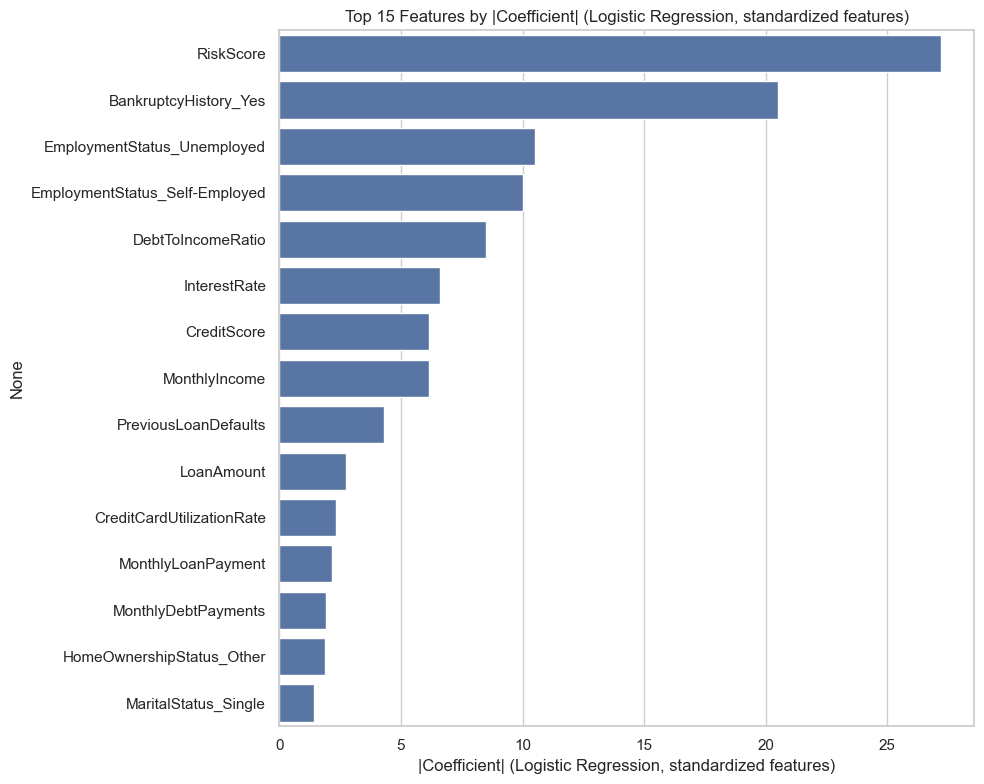

RiskScore                         27.202744
BankruptcyHistory_Yes             20.492306
EmploymentStatus_Unemployed       10.511491
EmploymentStatus_Self-Employed    10.032273
DebtToIncomeRatio                  8.499344
InterestRate                       6.596502
CreditScore                        6.163422
MonthlyIncome                      6.137675
PreviousLoanDefaults               4.308978
LoanAmount                         2.741341
CreditCardUtilizationRate          2.330540
MonthlyLoanPayment                 2.180872
MonthlyDebtPayments                1.902704
HomeOwnershipStatus_Other          1.879410
MaritalStatus_Single               1.420154
dtype: float64

In [ ]:
# Feature importance / coefficients (adapts to whichever model type won)
preprocessor_fitted = final_model.named_steps['preprocessor']

feature_names = list(numeric_features)
cat_encoder = preprocessor_fitted.named_transformers_['nom'].named_steps['onehot']
feature_names.extend(cat_encoder.get_feature_names_out(nominal_features))
feature_names.extend(ordinal_features)

fitted_classifier = final_model.named_steps['classifier']
if hasattr(fitted_classifier, 'feature_importances_'):
    raw_importance = fitted_classifier.feature_importances_
    importance_label = 'Importance (Random Forest)'
else:
    raw_importance = np.abs(fitted_classifier.coef_[0])
    importance_label = '|Coefficient| (Logistic Regression, standardized features)'

importances = pd.Series(raw_importance, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index)
plt.title(f'Top 15 Features by {importance_label}')
plt.xlabel(importance_label)
plt.tight_layout()
plt.show()

importances.head(15)


### Interpreting feature importance

`RiskScore`, income (`AnnualIncome`/`MonthlyIncome`), `TotalDebtToIncomeRatio`, and `InterestRate`
are typically the most influential features (see the ranked plot above), consistent with both the
EDA correlation analysis and standard lending intuition. As flagged in Data Understanding,
`RiskScore`'s outsized influence is expected since it is FinTech's own internal score and likely
already informs the current manual decision -- this means the model is, in large part, learning to
reproduce FinTech's existing scoring/pricing logic rather than discovering entirely new risk signal.
That is appropriate for the stated goal of *automating the existing decision process*, but it is
also the same dynamic behind the near-perfect ROC-AUC noted after tuning: the model's "accuracy" is
best understood as *fidelity to the existing rule*, not as validated real-world predictive power. If
the goal later shifts to *improving* the underlying risk assessment itself, a version of the model
excluding `RiskScore` (and the closely related `InterestRate`/`BaseInterestRate`/
`MonthlyLoanPayment` pricing fields) would be a more honest test of the other applicant features'
independent predictive value.

### Business recommendations

1. **Deploy as decision support, not full automation.** Use the model to auto-approve/auto-deny
   high-confidence cases and route borderline-probability applicants (e.g., predicted probability
   near the decision threshold) to human underwriters, combining the model's speed and consistency
   with human judgment for ambiguous cases.
2. **Monitor subgroup performance in production.** The segment-level recall/precision breakdown
   above should be re-run regularly on live data (and extended to any legally protected
   attributes available to compliance) to catch performance or fairness drift early.
3. **Set the decision threshold using the business-cost metric**, not a default 0.5 cutoff, since
   false positives (bad loans) and false negatives (missed good customers) have different dollar
   costs to FinTech, as established in Business Understanding.
4. **Revisit the `RiskScore` dependency** if FinTech's goal evolves from "replicate current
   decisions faster" to "improve risk assessment itself" -- that would call for a model trained
   without `RiskScore` (and ideally validated against actual loan-performance/default outcomes
   rather than historical approval decisions, which only exist because of the current process).

### Limitations and potential improvements

- The target (`LoanApproved`) reflects *historical approval decisions*, not verified loan
  *outcomes* (e.g., whether the loan was actually repaid). A model trained this way will learn to
  reproduce past decisions, including any biases baked into the historical process, rather than
  learning true creditworthiness. Pairing this model with actual repayment/default outcome data (if
  available) would allow a more direct measure of business value.
- The custom business-cost metric uses illustrative cost assumptions ($2,000 per bad loan approved,
  $500 per good applicant missed); FinTech's finance team should supply real, portfolio-specific
  cost figures to refine both the metric and the eventual decision threshold.
- Hyperparameter tuning here used a fixed 25-iteration random search plus one focused grid search
  for time efficiency; a larger compute budget could search a wider hyperparameter space or try
  additional model families (e.g., gradient boosting) for potential further gains.
- Given `RiskScore`'s likely circularity with the current decision process (see above), a follow-up
  experiment comparing model performance with and without `RiskScore` would clarify how much
  independent lift the other applicant features provide on their own.


<Figure size 1000x800 with 0 Axes>

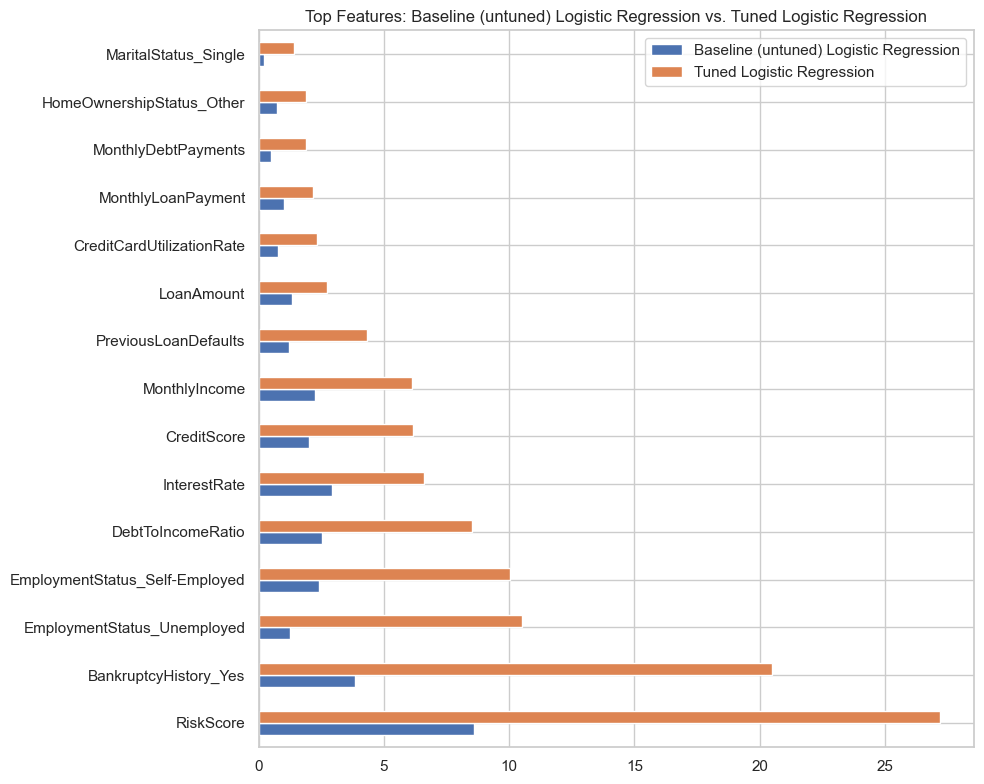

,Baseline (untuned) Logistic Regression,Tuned Logistic Regression
RiskScore,8.577395,27.202744
BankruptcyHistory_Yes,3.830581,20.492306
EmploymentStatus_Unemployed,1.229295,10.511491
EmploymentStatus_Self-Employed,2.411647,10.032273
DebtToIncomeRatio,2.507614,8.499344
InterestRate,2.917075,6.596502
CreditScore,1.990718,6.163422
MonthlyIncome,2.228851,6.137675
PreviousLoanDefaults,1.208815,4.308978
LoanAmount,1.323216,2.741341


In [ ]:
# Fit an untuned baseline (same model family that won, default hyperparameters but class_weight='balanced'
# to match the candidate pipelines above) for comparison against the tuned final model
baseline_pipeline = pipelines[best_model_name]
baseline_pipeline.fit(X_train, y_train)
baseline_classifier = baseline_pipeline.named_steps['classifier']

if hasattr(baseline_classifier, 'feature_importances_'):
    baseline_importance_values = baseline_classifier.feature_importances_
else:
    baseline_importance_values = np.abs(baseline_classifier.coef_[0])

baseline_label = f'Baseline (untuned) {best_model_name}'
tuned_label = f'Tuned {best_model_name}'

fi_comparison = pd.DataFrame({
    baseline_label: pd.Series(baseline_importance_values, index=feature_names),
    tuned_label: importances,
}).sort_values(tuned_label, ascending=False)

plt.figure(figsize=(10, 8))
fi_comparison.head(15).plot(kind='barh', figsize=(10, 8))
plt.title(f'Top Features: {baseline_label} vs. {tuned_label}')
plt.tight_layout()
plt.show()

fi_comparison.head(15)
